# Differentiable Viterbi decoding for linear-chain CRFs

Demo accompanying S. Strahl, J. Zeitler, M. Müller: *On the Use of Differentiable Viterbi Decoding
for Linear-Chain CRFs*, EUSIPCO 2026.

A linear-chain CRF combines local scores $\mathbf{S}$ with a transition model $\mathbf{T}$ and
picks the best overall state sequence by Viterbi decoding. Replacing the $\max$ operations of that
algorithm by the temperature-controlled $\max^\gamma$ (log-sum-exp) makes the decoded sequence
$\mathbf{\Theta}$ differentiable w.r.t. both $\mathbf{S}$ and $\mathbf{T}$, so the CRF can be used
as a module inside an end-to-end trainable pipeline.

In [1]:
from pathlib import Path

import librosa
import matplotlib.pyplot as plt
import torch
from matplotlib.colors import LogNorm

import utils
from dcrf import ToeplitzTransitions, dCRF

FIG_DIR = Path("figures")
FIG_DIR.mkdir(exist_ok=True)

### Score matrix $\mathbf{S}$

The example is a five-second excerpt of an opera recording: a female singing voice with pronounced
vibrato over orchestral accompaniment. The voice is the dominant source, and the goal is to follow
its F0 trajectory.

No neural network is involved here. We directly use a log-compressed VQT spectrogram (three bins per 
semitone, $K = 207$ frequency bins) as score matrix.

In [2]:
cfg = {
    "fs": 16000,
    "hop_size": 320,
    "f0_min": 32.7,
    "f0_max": 1760.0,
    "bins_per_semitone": 3,
    "filter_scale": 1,
    "norm": True,
    "basis_norm": 1,
    "gamma": 0,
    "window": "hann",
    "pad_mode": "reflect",
    "earlydownsample": True,
    "trainable": False,
    "output_format": "Magnitude",
    "verbose": False,
    "log_comp_gamma": 10,
}

In [3]:
fs = cfg["fs"]

x, _ = librosa.load("FMP_C8_F10_Weber_Freischuetz-06_FreiDi-35-40.wav", sr=fs, mono=True)
x = torch.from_numpy(x).float()

vqt = utils.VQTModule(**cfg)
S = vqt(x)  # (batch, time, freq)

n_frames, n_states = S.shape[1:]
t = torch.arange(n_frames) * cfg["hop_size"] / fs
f = vqt.frequencies_hz

print(f"Number of frequency bins: {n_states}")

Number of frequency bins: 207


/home/stst@alabsad.fau.de/miniconda3/envs/dcrf/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


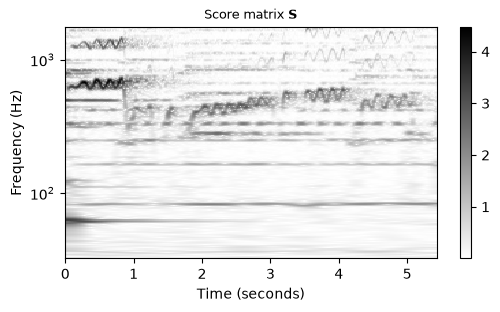

In [4]:
fig, ax = plt.subplots(figsize=(6, 3))
utils.plot_matrix(
    utils.plottable(S[0].T),
    t,
    f,
    ax,
    cmap="gray_r",
    title=r"Score matrix $\mathbf{S}$",
    colorbar=True
)
fig.savefig(FIG_DIR / "score_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

### Transition matrix $\mathbf{T}$

$\mathbf{T}(k, k')$ is the score of a transition from state $k$ in one frame to state $k'$ in the next.
An F0 trajectory moves smoothly, so we hand-craft $\mathbf{T}$ to favor small frequency changes: 
a score of $10$ within a band of 21 frequency bins, and $-10$ outside, which discourages large frequency 
jumps between frames.

The matrix is Toeplitz-structured, i.e. constant along its diagonals, so the cost of a transition
depends on the interval and not on the absolute frequency.

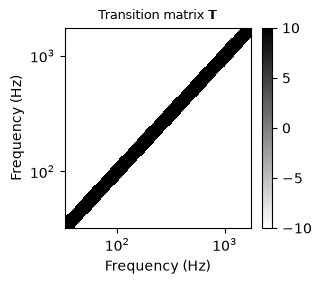

In [5]:
# a band of 21 diagonals, so that state changes of up to 10 steps per frame are cheap
diagonals = torch.full((2 * n_states - 1,), -10.0)
diagonals[n_states - 11 : n_states + 10] = 10.0

dcrf = dCRF(ToeplitzTransitions(n_states, diagonals=diagonals), gamma=1.0)

fig, ax = plt.subplots(figsize=(3, 2.6))
im = utils.plot_matrix(
    utils.plottable(dcrf.T),
    f,
    f,
    ax,
    cmap="gray_r",
    xlabel="Frequency (Hz)",
    xscale="log",
    title=r"Transition matrix $\mathbf{T}$",
    colorbar=True
)

fig.savefig(FIG_DIR / "transition_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

### Decoding at different temperatures $\gamma$

The temperature controls how soft the decoding is. For $\gamma \to 0$ it converges to the classical
Viterbi algorithm, and $\mathbf{\Theta}$ becomes the one-hot encoding of the single best sequence
$Q^*$ (top left). Larger $\gamma$ spreads probability mass over competing
sequences, visible as increasing blurriness around the F0 trajectory.

That softness is what makes the module useful inside a larger pipeline: $\mathbf{\Theta}$ is the
gradient of the sequence score w.r.t. $\mathbf{S}$, so gradients flow back through the decoding to
whatever produced the scores.

In [6]:
gammas = [0.3, 1.0, 3.0]
titles = [r"Classical Viterbi decoding ($\gamma \to 0$)"] + [rf"Differentiable Viterbi decoding ($\gamma = {gamma}$)" for gamma in gammas]

with torch.no_grad():
    decodings = []
    for gamma in [0.0] + gammas:  
        dcrf.gamma = torch.tensor(gamma)
        decodings.append(utils.plottable(dcrf(S)[0].T))

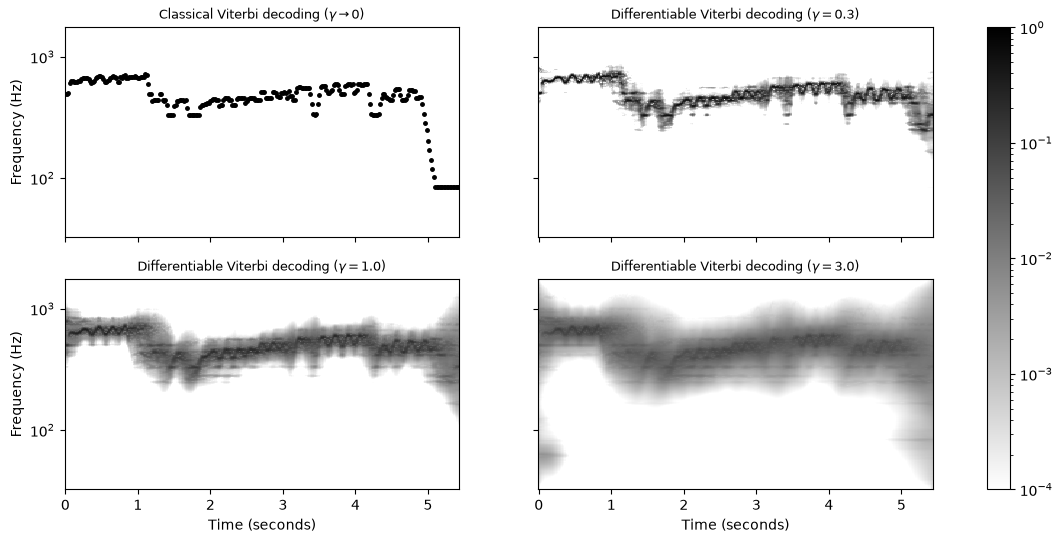

In [7]:
fig, axs = plt.subplots(2, 2, figsize=(14, 6), sharex=True, sharey=True)

for ax, title, decoding in zip(axs.flat[1:], titles[1:], decodings[1:]):
    im = utils.plot_matrix(
        decoding,
        t,
        f,
        ax,
        cmap="gray_r",
        norm=LogNorm(vmin=1e-4, vmax=1),
        xlabel="",
        ylabel="",
        title=title,
    )

ax = axs.flat[0]
ax.plot(utils.plottable(t), utils.plottable(f)[decodings[0].argmax(axis=0)], ".", ms=5, color="k")
ax.set_yscale("log")
ax.minorticks_off()
ax.set_title(titles[0], fontsize=9)

axs[1, 0].set_xlabel("Time (seconds)")
axs[1, 1].set_xlabel("Time (seconds)")
axs[0, 0].set_ylabel("Frequency (Hz)")
axs[1, 0].set_ylabel("Frequency (Hz)")

fig.colorbar(im, ax=axs)
fig.savefig(FIG_DIR / "decodings.png", dpi=150, bbox_inches="tight")
plt.show()